# 🌤️ MeteoSwiss Meteogram

Visualise the latest MeteoSwiss local forecast as a multi-panel meteogram.

**How to use:**
1. Run Cell 1 (setup) — only needed once
2. In Cell 2, set your `POI` — use a point ID (e.g. `"118802"`)
   - 💡 *Don't know your POI? Use the [POI Finder notebook](./poi_finder.ipynb) to search by name or PLZ*
3. Run all cells — your meteogram will appear at the bottom

**Data source:** [MeteoSwiss Open Data](https://data.geo.admin.ch) — updated every 6 hours

In [1]:
# =============================================================================
# Cell 1 — Setup: Imports & Constants
# =============================================================================

# --- Imports ---
import httpx
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import numpy as np
from datetime import datetime, timedelta
from zoneinfo import ZoneInfo
from io import StringIO
import asyncio

# --- Constants ---

# STAC API
STAC_BASE_URL = "https://data.geo.admin.ch/api/stac/v1"
COLLECTION_ID = "ch.meteoschweiz.ogd-local-forecasting"
METADATA_URL = f"https://data.geo.admin.ch/ch.meteoschweiz.ogd-local-forecasting/ogd-local-forecasting_meta_parameters.csv"

# Timezone
LOCAL_TZ = ZoneInfo("Europe/Zurich")
UTC_TZ = ZoneInfo("UTC")

# --- Load parameter metadata from OGD ---
meta_response = httpx.get(METADATA_URL, follow_redirects=True, timeout=30)
meta_response.raise_for_status()
meta_df = pd.read_csv(StringIO(meta_response.content.decode("latin-1")), sep=";")

# Build parameter lookups from metadata
PARAM_PANELS = dict(zip(meta_df["parameter_shortname"], meta_df["parameter_group_en"]))
DAILY_PARAMS = set(meta_df.loc[meta_df["parameter_granularity"] == "D", "parameter_shortname"])
PARAM_UNITS = dict(zip(meta_df["parameter_shortname"], meta_df["parameter_unit"]))
PARAM_DESCRIPTIONS = dict(zip(meta_df["parameter_shortname"], meta_df["parameter_description_en"]))

# Panel display order (top to bottom in the meteogram)
PANEL_ORDER = [
    "Temperature",
    "Precipitation",
    "Wind",
    "Sunshine",
    "Radiation",
    "Clouds",
]

# Color palette
COLORS = {
    # Temperature
    "temp_median": "#E31A1C",
    "temp_q_fill": "#FDCDCD",
    "temp_tmin": "#1F78B4",
    "temp_tmax": "#E31A1C",
    # Precipitation
    "precip_bar": "#6BAED6",
    "precip_q_fill": "#C6DBEF",
    "precip_prob": "#08519C",
    # Wind
    "wind_speed": "#33A02C",
    "wind_gust": "#FB9A99",
    "wind_q_fill_speed": "#D9F0D3",
    "wind_q_fill_gust": "#FDE0DD",
    # Sunshine
    "sunshine_bar": "#FFD700",
    # Radiation
    "radiation_global": "#FF8C00",
    "radiation_diffuse": "#FFA07A",
    # Clouds
    "cloud_low": "#636363",
    "cloud_mid": "#969696",
    "cloud_high": "#CCCCCC",
    # Zero degree level
    "zero_level": "#6A3D9A",
    # General
    "day_bg": "#FFFDE7",
    "night_bg": "#E8EAF6",
    "zero_line": "#999999",
}

# Matplotlib defaults
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.grid": True,
    "axes.grid.which": "major",
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
})

print(f"✓ Setup complete — {len(PARAM_PANELS)} parameters loaded from OGD metadata")

✓ Setup complete — 32 parameters loaded from OGD metadata


In [2]:
# =============================================================================
# Cell 2 — Configuration
# =============================================================================

# --- User settings (edit these) ---

# POI identifier: point_id
POI = "118800"

# Language for labels: "de", "fr", "it", "en"
LANG = "en"

# Panels to display — choose from PANEL_ORDER:
#   "Temperature", "Precipitation", "Wind", "Sunshine", "Radiation", "Clouds", "Graphics"
# Use "all" for all panels, or a list like ["Temperature", "Precipitation"]
PANELS = "all"

# --- Nothing to edit below this line ---
if PANELS == "all":
    selected_panels = PANEL_ORDER.copy()
else:
    selected_panels = [p for p in PANEL_ORDER if p in PANELS]

selected_params = [
    shortname for shortname, panel in PARAM_PANELS.items()
    if panel in selected_panels
]

print(f"POI:      {POI}")
print(f"Language: {LANG}")
print(f"Panels:   {', '.join(selected_panels)}")
print(f"Parameters to fetch: {len(selected_params)}")

POI:      118800
Language: en
Panels:   Temperature, Precipitation, Wind, Sunshine, Radiation, Clouds
Parameters to fetch: 30


In [3]:
# =============================================================================
# Cell 3 — Metadata Loading
# =============================================================================

# --- 3a. Load POI / point metadata (collection-level asset) ---
META_POINT_URL = (
    f"https://data.geo.admin.ch/{COLLECTION_ID}/"
    "ogd-local-forecasting_meta_point.csv"
)

with httpx.Client() as client:
    resp = client.get(META_POINT_URL, follow_redirects=True, timeout=30)
    resp.raise_for_status()
    df_meta_point = pd.read_csv(StringIO(resp.content.decode("latin-1")), sep=";")
    print(f"✓ Points available: {len(df_meta_point)}")

# --- 3b. Get today's STAC item directly ---
today_id = f"{datetime.now(LOCAL_TZ).strftime('%Y%m%d')}-ch"
stac_item_url = f"{STAC_BASE_URL}/collections/{COLLECTION_ID}/items/{today_id}"

with httpx.Client() as client:
    response = client.get(stac_item_url)
    response.raise_for_status()
    stac_item = response.json()

assets = stac_item["assets"]

# Extract actual run time from asset filename
sample_key = list(assets.keys())[0]
run_time = sample_key.split(".")[2]  # e.g. "202605150700"
runtime_dt = datetime.strptime(run_time, "%Y%m%d%H%M").replace(tzinfo=ZoneInfo("UTC")).astimezone(LOCAL_TZ)

print(f"✅ Item: {today_id}")
print(f"   Run time: {runtime_dt.strftime('%Y-%m-%d %H:%M %Z')}")
print(f"   Data assets: {len(assets)}")

# --- 3c. Resolve the selected POI (by point_id only) ---
poi_match = df_meta_point[df_meta_point["point_id"] == int(POI)]
if len(poi_match) == 0:
    print(f"\n⚠ POI with point_id={POI} not found.")
    print("Here are some valid point IDs:")
    sample = df_meta_point[["point_id", "station_abbr", "point_name"]].head(20)
    display(sample.to_string(index=False))
    raise ValueError(f"point_id {POI} not found in metadata.")

poi_row = poi_match.iloc[0]
print(f"\n✓ Selected POI:")
print(f"  ID:    {poi_row['point_id']}")
print(f"  Abbr:  {poi_row['station_abbr']}")
print(f"  Name:  {poi_row['point_name']}")

# Store data asset URLs for download (step 5)
data_assets = {k: v["href"] for k, v in assets.items()}
print(f"\n✓ Metadata loaded — {len(data_assets)} data assets available for download")

✓ Points available: 5629
✅ Item: 20260515-ch
   Run time: 2026-05-15 02:00 CEST
   Data assets: 352

✓ Selected POI:
  ID:    118800
  Abbr:  nan
  Name:  Gimel

✓ Metadata loaded — 352 data assets available for download


In [4]:
# =============================================================================
# Cell 4 — Parameter Overview Table
# =============================================================================

# --- Build the overview table from metadata ---

# Select the description column based on chosen language
desc_col = f"parameter_description_{LANG}"
group_col = f"parameter_group_{LANG}"

# Check which language columns are available
available_langs = [c for c in meta_df.columns if "description" in c]
if desc_col not in meta_df.columns:
    print(f"⚠ Language '{LANG}' not found. Available: {available_langs}")
    desc_col = available_langs[0]
    group_col = [c for c in meta_df.columns if "group" in c][0]

# Build overview table
df_overview = meta_df[
    ["parameter_shortname", desc_col, group_col, "parameter_unit", "parameter_granularity"]
].copy()
df_overview.columns = ["Shortname", "Description", "Panel", "Unit", "Granularity"]

# Mark which parameters are selected for the current run
df_overview["Selected"] = df_overview["Shortname"].isin(selected_params).map(
    {True: "✓", False: ""}
)

# Sort by panel order, then shortname
panel_order_map = {p: i for i, p in enumerate(PANEL_ORDER)}
df_overview["_sort"] = df_overview["Panel"].map(panel_order_map).fillna(99)
df_overview = df_overview.sort_values(["_sort", "Shortname"]).drop(columns="_sort")

# Display grouped by panel
print(f"Parameter overview (language: {LANG})")
print(f"{'=' * 80}")
for panel in PANEL_ORDER:
    panel_params = df_overview[df_overview["Panel"] == panel]
    if len(panel_params) > 0:
        print(f"\n  {panel.upper()}")
        print(f"  {'-' * 76}")
        for _, row in panel_params.iterrows():
            sel = row["Selected"]
            gran = "hourly" if row["Granularity"] == "H" else "daily "
            print(
                f"  {sel:>1}  {row['Shortname']:<12} {gran}  "
                f"{row['Unit']:<8} {row['Description']}"
            )

# Also show as a full interactive table
print(f"\n{'=' * 80}")
print(f"Total: {len(df_overview)} parameters, {df_overview['Selected'].str.contains('✓').sum()} selected\n")
display(df_overview.reset_index(drop=True))

Parameter overview (language: en)

  TEMPERATURE
  ----------------------------------------------------------------------------
  ✓  tre200dn     daily   °C       Air temperature 2 m above ground; daily minimum
  ✓  tre200dx     daily   °C       Air temperature 2 m above ground; daily maximum
  ✓  tre200h0     hourly  °C       Air temperature 2 m above ground; hourly mean
  ✓  tre200pn     daily   °C       Air temperature 2 m above ground; daily minimum 00:00 - 24:00 local time
  ✓  tre200px     daily   °C       Air temperature 2 m above ground; daily maximum 00:00 - 24:00 local time
  ✓  treq10h0     hourly  °C       Air temperature 2 m above ground; hourly mean, 10% quantile
  ✓  treq90h0     hourly  °C       Air temperature 2 m above ground; hourly mean, 90% quantile
  ✓  zprfr0hs     hourly  m        Zero degree level; hourly value, forecast

  PRECIPITATION
  ----------------------------------------------------------------------------
  ✓  rka150d0     daily   mm       Precipitati

,Shortname,Description,Panel,Unit,Granularity,Selected
0,tre200dn,Air temperature 2 m above ground; daily minimum,Temperature,°C,D,✓
1,tre200dx,Air temperature 2 m above ground; daily maximum,Temperature,°C,D,✓
2,tre200h0,Air temperature 2 m above ground; hourly mean,Temperature,°C,H,✓
3,tre200pn,Air temperature 2 m above ground; daily minimu...,Temperature,°C,D,✓
4,tre200px,Air temperature 2 m above ground; daily maximu...,Temperature,°C,D,✓
5,treq10h0,"Air temperature 2 m above ground; hourly mean,...",Temperature,°C,H,✓
6,treq90h0,"Air temperature 2 m above ground; hourly mean,...",Temperature,°C,H,✓
7,zprfr0hs,"Zero degree level; hourly value, forecast",Temperature,m,H,✓
8,rka150d0,Precipitation; daily total 0 UTC - 0 UTC,Precipitation,mm,D,✓
9,rka150p0,Precipitation; daily total 00:00 - 24:00 local...,Precipitation,mm,D,✓


In [5]:
# =============================================================================
# Cell 5 — Data Download
# =============================================================================

# --- 5a. Map selected parameters to asset URLs ---
param_urls = {}
for param in selected_params:
    matching_keys = [k for k in data_assets if param in k]
    if matching_keys:
        param_urls[param] = data_assets[matching_keys[0]]
    else:
        print(f"⚠ No asset found for parameter: {param}")

print(f"Parameters to download: {len(param_urls)} / {len(selected_params)}")

# --- 5b. Download all CSVs in parallel ---
async def download_all(urls_dict):
    """Download all parameter CSVs in parallel, return dict of param → raw bytes."""
    results = {}
    async with httpx.AsyncClient(timeout=30.0) as client:
        tasks = {
            param: client.get(url)
            for param, url in urls_dict.items()
        }
        responses = {}
        for param, coro in tasks.items():
            responses[param] = await coro

        for param, resp in responses.items():
            if resp.status_code == 200:
                results[param] = resp.content
            else:
                print(f"⚠ Failed to download {param}: HTTP {resp.status_code}")
    return results

raw_data = await download_all(param_urls)
print(f"✓ Downloaded {len(raw_data)} / {len(param_urls)} parameter files")

# --- 5c. Parse into DataFrames, filter for selected POI ---
poi_id = str(poi_row["point_id"])
dfs_hourly = {}
dfs_daily = {}

for param, content in raw_data.items():
    try:
        df = pd.read_csv(StringIO(content.decode("latin-1")), sep=";")

        # Filter for selected POI
        id_col = [c for c in df.columns if "station" in c.lower() or "point" in c.lower() or "id" in c.lower()][0]
        df_poi = df[df[id_col].astype(str) == poi_id]

        if len(df_poi) == 0:
            print(f"⚠ No data for POI {poi_id} in {param}")
            continue

        if param in DAILY_PARAMS:
            dfs_daily[param] = df_poi
        else:
            dfs_hourly[param] = df_poi

    except Exception as e:
        print(f"⚠ Error parsing {param}: {e}")

print(f"\n✓ Parsed — Hourly params: {len(dfs_hourly)}, Daily params: {len(dfs_daily)}")

# --- 5d. Print date ranges ---
def print_date_range(label, dfs):
    if not dfs:
        return
    all_dates = pd.to_datetime(
        pd.concat([df["Date"] for df in dfs.values() if "Date" in df.columns])
    )
    date_min = all_dates.min()
    date_max = all_dates.max()
    horizon_hours = (date_max - date_min).total_seconds() / 3600
    print(
        f"{label} date range: "
        f"{date_min.strftime('%Y-%m-%d %H:%M')} → "
        f"{date_max.strftime('%Y-%m-%d %H:%M')} "
        f"({horizon_hours:.0f} h)"
    )

print_date_range("Hourly", dfs_hourly)
print_date_range("Daily", dfs_daily)

# --- 5e. Show a sample to inspect the data structure ---
if dfs_hourly:
    sample_param = list(dfs_hourly.keys())[0]
    print(f"\nSample hourly data ({sample_param}):")
    print(f"Columns: {list(dfs_hourly[sample_param].columns)}")
    display(dfs_hourly[sample_param].head(3))

if dfs_daily:
    sample_param = list(dfs_daily.keys())[0]
    print(f"\nSample daily data ({sample_param}):")
    print(f"Columns: {list(dfs_daily[sample_param].columns)}")
    display(dfs_daily[sample_param].head(3))

Parameters to download: 30 / 30
✓ Downloaded 30 / 30 parameter files
⚠ No data for POI 118800 in rka150d0
⚠ No data for POI 118800 in tre200dn
⚠ No data for POI 118800 in tre200dx

✓ Parsed — Hourly params: 22, Daily params: 5
Hourly date range: 1970-01-01 00:03 → 1970-01-01 00:03 (0 h)
Daily date range: 1970-01-01 00:03 → 1970-01-01 00:03 (0 h)

Sample hourly data (dkl010h0):
Columns: ['point_id', 'point_type_id', 'Date', 'dkl010h0']


,point_id,point_type_id,Date,dkl010h0
237820,118800,2,202605142100,235
237821,118800,2,202605142200,234
237822,118800,2,202605142300,230



Sample daily data (rka150p0):
Columns: ['point_id', 'point_type_id', 'Date', 'rka150p0']


,point_id,point_type_id,Date,rka150p0
9729,118800,2,202605150000,6.3
9730,118800,2,202605160000,1.3
9731,118800,2,202605170000,0.0


In [6]:
# =============================================================================
# Cell 6 — Data Parsing
# =============================================================================

# --- Column names ---

sample_df = list(dfs_hourly.values())[0] if dfs_hourly else list(dfs_daily.values())[0]
time_col = [c for c in sample_df.columns if "date" in c.lower() or "time" in c.lower()][0]

# --- Build df_hourly ---

df_hourly = pd.DataFrame()

for param, df in dfs_hourly.items():
    df_temp = df.copy()
    df_temp[time_col] = pd.to_datetime(df_temp[time_col].astype(int).astype(str), format="%Y%m%d%H%M", utc=True)
    df_temp[time_col] = df_temp[time_col].dt.tz_convert(LOCAL_TZ)
    
    value_col = [c for c in df_temp.columns if c != time_col
                 and "station" not in c.lower()
                 and "point" not in c.lower()
                 and "id" not in c.lower()][0]
    
    df_temp = df_temp.set_index(time_col)[[value_col]].rename(columns={value_col: param})
    df_temp[param] = pd.to_numeric(df_temp[param], errors="coerce")
    
    df_hourly = df_temp if df_hourly.empty else df_hourly.join(df_temp, how="outer")

df_hourly = df_hourly.sort_index()

print(f"✓ df_hourly: {df_hourly.shape[0]} timesteps × {df_hourly.shape[1]} parameters")
print(f"  Range: {df_hourly.index[0].strftime('%Y-%m-%d %H:%M')} → {df_hourly.index[-1].strftime('%Y-%m-%d %H:%M')}")
display(df_hourly.head())

# --- Build df_daily ---

df_daily = pd.DataFrame()

for param, df in dfs_daily.items():
    df_temp = df.copy()
    df_temp[time_col] = pd.to_datetime(df_temp[time_col].astype(int).astype(str), format="%Y%m%d%H%M", utc=True)
    df_temp[time_col] = df_temp[time_col].dt.tz_convert(LOCAL_TZ).dt.normalize()
    
    value_col = [c for c in df_temp.columns if c != time_col
                 and "station" not in c.lower()
                 and "point" not in c.lower()
                 and "id" not in c.lower()][0]
    
    df_temp = df_temp.set_index(time_col)[[value_col]].rename(columns={value_col: param})
    df_temp[param] = pd.to_numeric(df_temp[param], errors="coerce")
    
    df_daily = df_temp if df_daily.empty else df_daily.join(df_temp, how="outer")

if not df_daily.empty:
    df_daily = df_daily.sort_index()
    print(f"\n✓ df_daily: {df_daily.shape[0]} days × {df_daily.shape[1]} parameters")
    print(f"  Range: {df_daily.index[0].strftime('%Y-%m-%d')} → {df_daily.index[-1].strftime('%Y-%m-%d')}")
    display(df_daily.head())
else:
    print(f"\n✓ df_daily: empty (all selected parameters are hourly)")

✓ df_hourly: 220 timesteps × 22 parameters
  Range: 2026-05-14 23:00 → 2026-05-24 02:00


,dkl010h0,fu3010h0,fu3010h1,fu3q10h0,fu3q10h1,fu3q90h0,fu3q90h1,gre000h0,nprohihs,nprolohs,...,rp0003i0,rre003i0,rre150h0,rreq10h0,rreq90h0,sre000h0,tre200h0,treq10h0,treq90h0,zprfr0hs
Date,,,,,,,,,,,,,,,,,,,,,
2026-05-14 23:00:00+02:00,235,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,4.2,4.2,4.2,1449
2026-05-15 00:00:00+02:00,234,13.4,23.5,13.4,23.5,13.4,23.5,0,0.00,0.69,...,NaN,NaN,0.0,0.0,0.0,0.0,4.4,4.4,4.4,1434
2026-05-15 01:00:00+02:00,230,12.8,23.2,12.8,23.2,12.8,23.2,0,0.06,0.66,...,NaN,NaN,0.0,0.0,0.0,0.0,4.2,4.2,4.2,1407
2026-05-15 02:00:00+02:00,228,10.0,16.8,10.0,16.8,10.0,16.8,0,0.01,0.41,...,0.0,0.0,0.0,0.0,0.0,0.0,4.1,4.1,4.1,1387
2026-05-15 03:00:00+02:00,234,8.9,15.7,6.5,10.7,13.4,22.9,0,0.31,0.50,...,0.0,0.0,0.0,0.0,0.0,0.0,4.2,3.9,4.4,1378



✓ df_daily: 9 days × 5 parameters
  Range: 2026-05-15 → 2026-05-23


,rka150p0,rreq10p0,rreq90p0,tre200pn,tre200px
Date,,,,,
2026-05-15 00:00:00+02:00,6.3,2.0,12.9,4.1,8.0
2026-05-16 00:00:00+02:00,1.3,0.0,4.1,2.3,9.4
2026-05-17 00:00:00+02:00,0.0,0.0,0.4,1.3,14.0
2026-05-18 00:00:00+02:00,1.7,0.0,8.6,5.5,13.9
2026-05-19 00:00:00+02:00,0.0,0.0,1.2,5.1,16.4


In [7]:
# =============================================================================
# Cell 7 — Panel Plot Functions
# =============================================================================

def plot_temperature(ax):
    """Temperature: median line + Q10/Q90 band + daily Tmin/Tmax + zero-degree level."""
    # Hourly median + uncertainty band
    if "tre200h0" in df_hourly:
        ax.plot(df_hourly.index, df_hourly["tre200h0"], color=COLORS["temp_median"], lw=1.5, label="T median")
    if "treq10h0" in df_hourly and "treq90h0" in df_hourly:
        ax.fill_between(df_hourly.index, df_hourly["treq10h0"], df_hourly["treq90h0"],
                        color=COLORS["temp_q_fill"], alpha=0.5, label="Q10–Q90")

    # Daily Tmin / Tmax markers — centred at noon
    dates_noon = df_daily.index + pd.Timedelta(hours=12)
    if "tre200pn" in df_daily:
        ax.scatter(dates_noon, df_daily["tre200pn"], color=COLORS["temp_tmin"],
                   marker="v", s=30, zorder=5, label="Tmin")
    if "tre200px" in df_daily:
        ax.scatter(dates_noon, df_daily["tre200px"], color=COLORS["temp_tmax"],
                   marker="^", s=30, zorder=5, label="Tmax")

    # Zero degree reference line
    ax.axhline(0, color=COLORS["zero_line"], lw=0.5, ls="--")
    ax.set_ylabel(PARAM_UNITS.get("tre200h0", "°C"))

    # Zero-degree level on secondary axis (different unit: meters)
    if "zprfr0hs" in df_hourly:
        ax2 = ax.twinx()
        ax2.plot(df_hourly.index, df_hourly["zprfr0hs"], color=COLORS["zero_level"], lw=1.2, label="0°C level")

        elev_cols = [c for c in poi_row.index if "elev" in c.lower() or "height" in c.lower() or "alt" in c.lower()]
        if elev_cols:
            station_elev = poi_row[elev_cols[0]]
            ax2.axhline(station_elev, color=COLORS["zero_line"], lw=0.8, ls=":",
                       label=f"Station ({station_elev:.0f} m)")
        ax2.set_ylabel(PARAM_UNITS.get("zprfr0hs", "m"))

        lines1, labels1 = ax.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=7, ncol=5)
    else:
        ax.legend(loc="upper right", fontsize=7, ncol=4)

    ax.set_title("Temperature")


def plot_precipitation(ax):
    """Precipitation: hourly bars + Q10/Q90 + probability line."""
    ax2 = ax.twinx()

    # Hourly precipitation bars
    if "rre150h0" in df_hourly:
        ax.bar(df_hourly.index, df_hourly["rre150h0"], width=1/24,
               color=COLORS["precip_bar"], alpha=0.7, label="Precip median")

    # Q10/Q90 band
    if "rreq10h0" in df_hourly and "rreq90h0" in df_hourly:
        ax.fill_between(df_hourly.index, df_hourly["rreq10h0"], df_hourly["rreq90h0"],
                        color=COLORS["precip_q_fill"], alpha=0.4, label="Q10–Q90")

    # Probability of precipitation (right axis)
    if "rp0003i0" in df_hourly:
        ax2.plot(df_hourly.index, df_hourly["rp0003i0"], color=COLORS["precip_prob"],
                 lw=1, ls="--", label="Prob. precip")
        ax2.set_ylabel(PARAM_UNITS.get("rp0003i0", "%"))
        ax2.set_ylim(0, 105)
        ax2.legend(loc="upper left", fontsize=7)

    ax.set_ylabel(PARAM_UNITS.get("rre150h0", "mm"))
    ax.set_title("Precipitation (hourly)")
    ax.legend(loc="upper right", fontsize=7)


def plot_daily_precip(ax):
    """Daily precipitation: median bar with Q10–Q90 whiskers, centred at noon."""
    dates_noon = df_daily.index + pd.Timedelta(hours=12)
    positions = mdates.date2num(dates_noon)

    has_q10 = "rreq10p0" in df_daily
    has_q90 = "rreq90p0" in df_daily
    has_median = "rka150p0" in df_daily

    if not has_median:
        ax.text(0.5, 0.5, "No daily precipitation data", transform=ax.transAxes, ha="center")
        return

    median = df_daily["rka150p0"].values
    q10 = df_daily["rreq10p0"].values if has_q10 else median
    q90 = df_daily["rreq90p0"].values if has_q90 else median

    bar_width = 0.5
    cap_width = 0.3

    # Median bars
    ax.bar(positions, median, width=bar_width,
           color=COLORS["precip_bar"], alpha=0.7, zorder=3)

    # Q10–Q90 whiskers on top of bars
    for i, pos in enumerate(positions):
        ax.vlines(pos, q10[i], q90[i], color="steelblue", linewidth=1.5, zorder=4)
        ax.hlines(q10[i], pos - cap_width / 2, pos + cap_width / 2,
                  color="steelblue", linewidth=1.5, zorder=4)
        ax.hlines(q90[i], pos - cap_width / 2, pos + cap_width / 2,
                  color="steelblue", linewidth=1.5, zorder=4)

    # Legend
    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D
    legend_elements = [
        Patch(facecolor=COLORS["precip_bar"], alpha=0.7, label="Median"),
        Line2D([0], [0], color="steelblue", linewidth=1.5, label="Q10–Q90"),
    ]
    ax.legend(handles=legend_elements, loc="upper right", fontsize=7, ncol=2)

    ax.set_ylim(bottom=0)
    ax.set_ylabel(PARAM_UNITS.get("rka150p0", "mm"))
    ax.set_title("Daily Precipitation")
    ax.xaxis.set_major_locator(mdates.DayLocator(tz=LOCAL_TZ))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%a\n%d.%m", tz=LOCAL_TZ))
    ax.set_xlim(df_hourly.index[0], df_hourly.index[-1])


def plot_wind(ax):
    """Wind: speed/gust lines + Q10/Q90 bands + direction arrows."""
    # Wind speed
    if "fu3010h0" in df_hourly:
        ax.plot(df_hourly.index, df_hourly["fu3010h0"], color=COLORS["wind_speed"], lw=1.2, label="Speed")
    if "fu3q10h0" in df_hourly and "fu3q90h0" in df_hourly:
        ax.fill_between(df_hourly.index, df_hourly["fu3q10h0"], df_hourly["fu3q90h0"],
                        color=COLORS["wind_q_fill_speed"], alpha=0.4, label="Speed Q10–Q90")

    # Wind gusts
    if "fu3010h1" in df_hourly:
        ax.plot(df_hourly.index, df_hourly["fu3010h1"], color=COLORS["wind_gust"], lw=1, ls="--", label="Gust")
    if "fu3q10h1" in df_hourly and "fu3q90h1" in df_hourly:
        ax.fill_between(df_hourly.index, df_hourly["fu3q10h1"], df_hourly["fu3q90h1"],
                        color=COLORS["wind_q_fill_gust"], alpha=0.3, label="Gust Q10–Q90")

    # Wind direction arrows (every 3 hours to avoid clutter)
    if "dkl010h0" in df_hourly and "fu3010h0" in df_hourly:
        step = 3
        times = df_hourly.index[::step]
        dirs_deg = df_hourly["dkl010h0"].iloc[::step].values

        dirs_rad = np.deg2rad(dirs_deg)
        u = -np.sin(dirs_rad)
        v = -np.cos(dirs_rad)

        x_pos = mdates.date2num(times)
        y_pos = np.full(len(times), ax.get_ylim()[1] * 0.85 if ax.get_ylim()[1] > 0 else 10)

        ax.quiver(x_pos, y_pos, u, v,
                  angles="uv", pivot="middle",
                  scale=100, width=0.001,
                  headwidth=3, headlength=4, headaxislength=3.5,
                  color="black", zorder=5)

    ax.set_ylabel(PARAM_UNITS.get("fu3010h0", "km/h"))
    ax.set_title("Wind")
    ax.legend(loc="upper right", fontsize=7, ncol=4)


def plot_sunshine(ax):
    """Sunshine duration bars."""
    if "sre000h0" in df_hourly:
        ax.bar(df_hourly.index - pd.Timedelta(minutes=30), df_hourly["sre000h0"], width=1/24,
               color=COLORS["sunshine_bar"], alpha=0.7, label="Sunshine")

    ax.set_ylim(0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 60)
    ax.set_xlim(df_hourly.index[0], df_hourly.index[-1])
    ax.set_ylabel(PARAM_UNITS.get("sre000h0", "min"))
    ax.set_title("Sunshine")
    ax.legend(loc="upper right", fontsize=7)


def plot_radiation(ax):
    """Global and diffuse radiation lines."""
    if "gre000h0" in df_hourly:
        ax.plot(df_hourly.index, df_hourly["gre000h0"], color=COLORS["radiation_global"],
                lw=1, label="Global")
    if "ods000h0" in df_hourly:
        ax.plot(df_hourly.index, df_hourly["ods000h0"], color=COLORS["radiation_diffuse"],
                lw=1, ls="--", label="Diffuse")

    ax.set_ylim(0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 1)
    ax.set_xlim(df_hourly.index[0], df_hourly.index[-1])
    ax.set_ylabel(PARAM_UNITS.get("gre000h0", "W/m²"))
    ax.set_title("Radiation")
    ax.legend(loc="upper right", fontsize=7)


def plot_clouds(ax):
    """Cloud cover: stacked area (low/mid/high)."""
    cloud_params = {
        "nprolohs": ("Low", COLORS["cloud_low"]),
        "npromths": ("Mid", COLORS["cloud_mid"]),
        "nprohihs": ("High", COLORS["cloud_high"]),
    }

    available = {k: v for k, v in cloud_params.items() if k in df_hourly}

    if available:
        labels = [v[0] for v in available.values()]
        colors = [v[1] for v in available.values()]
        data = [df_hourly[k].fillna(0).values * 100 for k in available.keys()]
        ax.stackplot(df_hourly.index, *data, labels=labels, colors=colors, alpha=0.6)
        ax.set_ylim(0, 100)

    ax.set_ylabel("%")
    ax.set_title("Clouds")
    ax.legend(loc="upper right", fontsize=7, ncol=3)


# --- Panel dispatcher ---
PANEL_FUNCTIONS = {
    "Temperature":   [plot_temperature],
    "Precipitation": [plot_precipitation, plot_daily_precip],
    "Wind":          [plot_wind],
    "Sunshine":      [plot_sunshine],
    "Radiation":     [plot_radiation],
    "Clouds":        [plot_clouds],
    }

print(f"✓ {len(PANEL_FUNCTIONS)} panel groups defined "
      f"({sum(len(v) for v in PANEL_FUNCTIONS.values())} plot functions)")

✓ 6 panel groups defined (7 plot functions)


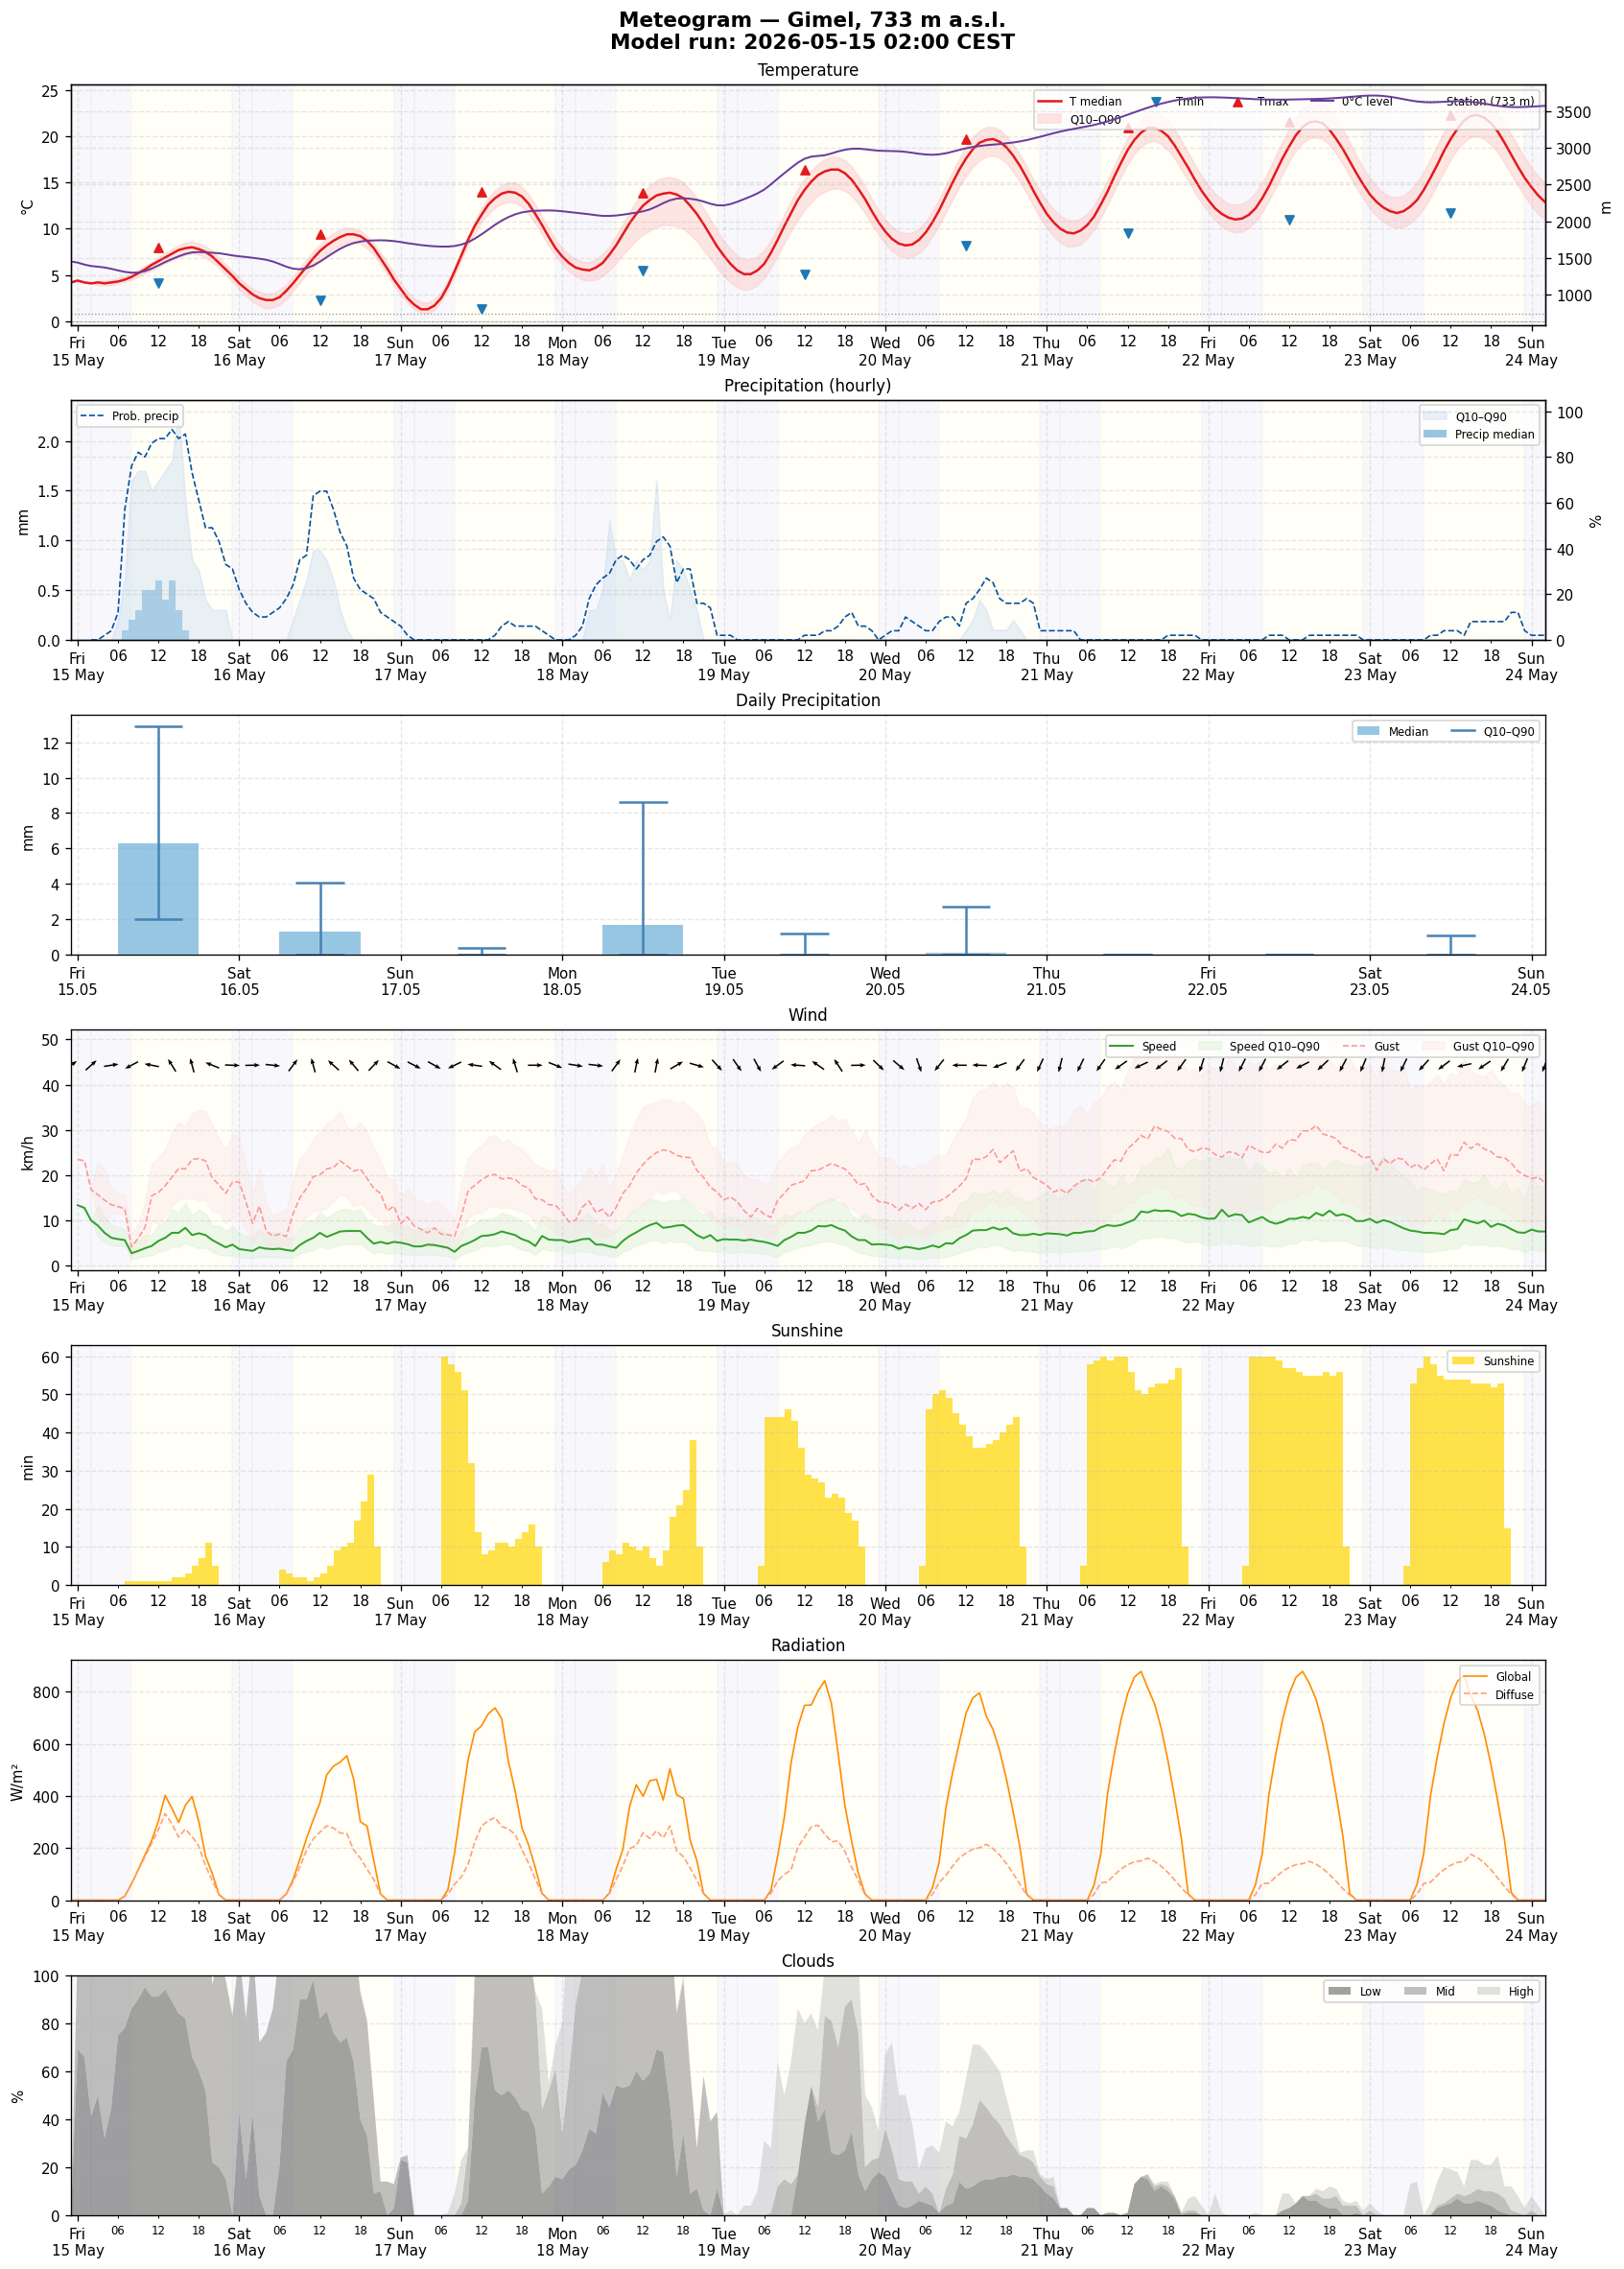

✓ Meteogram rendered


In [8]:
# =============================================================================
# Cell 8 — Plot Assembly
# =============================================================================
from matplotlib.gridspec import GridSpec

# --- Day/night shading helper ---
def add_day_night_shading(ax):
    """Add day/night background shading based on approximate sunrise/sunset."""
    xlim = mdates.num2date(ax.get_xlim())
    start = xlim[0].replace(hour=0, minute=0)
    end = xlim[1]

    current = start
    while current < end:
        sunrise = current.replace(hour=6, minute=0)
        sunset = current.replace(hour=21, minute=0)
        next_day = current + timedelta(days=1)

        ax.axvspan(current, sunrise, color=COLORS["night_bg"], alpha=0.3, zorder=0)
        ax.axvspan(sunrise, sunset, color=COLORS["day_bg"], alpha=0.3, zorder=0)
        ax.axvspan(sunset, next_day, color=COLORS["night_bg"], alpha=0.3, zorder=0)

        current = next_day


def format_time_axis(ax, is_bottom=False):
    """Format x-axis with date/time labels."""
    ax.xaxis.set_major_locator(mdates.DayLocator(tz=LOCAL_TZ))
    ax.xaxis.set_minor_locator(mdates.HourLocator(byhour=[6, 12, 18], tz=LOCAL_TZ))

    if is_bottom:
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%a\n%d %b", tz=LOCAL_TZ))
        ax.xaxis.set_minor_formatter(mdates.DateFormatter("%H", tz=LOCAL_TZ))
        ax.tick_params(axis="x", which="minor", labelsize=7)
    else:
        ax.xaxis.set_major_formatter(mdates.DateFormatter(""))
        ax.xaxis.set_minor_formatter(mdates.DateFormatter(""))


# --- Count total axes needed (precipitation has 2: hourly + daily) ---
n_axes = sum(len(PANEL_FUNCTIONS[p]) for p in selected_panels)

# --- Build figure with GridSpec (daily panel gets independent x-axis) ---
fig = plt.figure(figsize=(14, 2.8 * n_axes))
gs = GridSpec(n_axes, 1, figure=fig)

# Track which axes are hourly (shared x) vs daily (independent x)
axes_all = []
axes_hourly = []
ax_first_hourly = None
is_daily = []

i = 0
for panel_name in selected_panels:
    for func in PANEL_FUNCTIONS.get(panel_name, []):
        daily = (func == plot_daily_precip)
        is_daily.append(daily)

        if daily:
            # Daily panel: independent x-axis
            ax = fig.add_subplot(gs[i])
        else:
            # Hourly panel: share x-axis with the first hourly panel
            if ax_first_hourly is None:
                ax = fig.add_subplot(gs[i])
                ax_first_hourly = ax
            else:
                ax = fig.add_subplot(gs[i], sharex=ax_first_hourly)

        axes_all.append((ax, func, daily))
        i += 1

# --- Plot each panel ---
for idx, (ax, func, daily) in enumerate(axes_all):
    func(ax)

    if not daily:
        add_day_night_shading(ax)
        # Only the last hourly panel gets time labels
        is_last_hourly = all(d for _, _, d in axes_all[idx + 1:])
        format_time_axis(ax, is_bottom=is_last_hourly)
        ax.set_xlim(df_hourly.index[0], df_hourly.index[-1])

# --- Title ---
poi_name = poi_row.get("point_name", POI)
elev_cols = [c for c in poi_row.index if "elev" in c.lower() or "height" in c.lower() or "alt" in c.lower()]
elev_str = f", {poi_row[elev_cols[0]]:.0f} m a.s.l." if elev_cols else ""

fig.suptitle(
    f"Meteogram — {poi_name}{elev_str}\n"
    f"Model run: {runtime_dt.strftime('%Y-%m-%d %H:%M %Z')}",
    fontsize=13, fontweight="bold",
)

fig.set_layout_engine("constrained")
plt.show()
print("✓ Meteogram rendered")

fig.savefig("meteogram.png", dpi=150, bbox_inches="tight")